# Notebook 03 — Cálculo de Impedâncias (Tempos de Viagem Multimodal)

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA
**Programa:** MAPEPROF — Mestrado Profissional em Planejamento Urbano e Regional / IFPI
**Autor:** Felipe Ramos Dantas
**Orientador:** Prof. Dr. Antonio Joaquim da Silva
**Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs
**Última atualização:** 2026-06-14

---
## Objetivo
Converter a malha viária classificada (NB 02.2) em um **grafo ponderado por tempo de
viagem** (impedância, em minutos), para os modos **automóvel** e **pedestre**. Cada
aresta recebe um custo de travessia que alimentará o roteamento e a geração de
isócronas (NB 04).

## Entrada
| Arquivo | Origem |
|---|---|
| `dados/intermediarios/02_grafo/zonaUrbana_5km_road_imputed.parquet` | NB 02.2 |

## Saída
| Arquivo | Consumido por |
|---|---|
| `dados/intermediarios/04_impedancias/zonaUrbana_5km_road_routed.parquet` | NB 04 (isócronas) |

## Pré-requisitos
- NB 02.2 executado. Ambiente `.venv` com o pacote `mapeprof`.
---

In [1]:
# ── 1. IMPORTAÇÕES E CONFIGURAÇÃO ───────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from mapeprof.config import (INT_GRAFO, INT_IMPEDANCIAS, EXT_IBGE,
                             FIGURAS, TABELAS, CRS_METRICO, criar_diretorios)
from mapeprof.viz import (aplicar_estilo, barra_escala, seta_norte, moldura_mapa,
                          formatar_eixos_mapa, ajustar_zoom_camada)

aplicar_estilo()
warnings.filterwarnings("ignore")
criar_diretorios()
FIGURAS_NB = FIGURAS / "nb031"; FIGURAS_NB.mkdir(parents=True, exist_ok=True)
TABELAS_NB = TABELAS / "nb031"; TABELAS_NB.mkdir(parents=True, exist_ok=True)

print("✅ Setup concluído.")

✅ Setup concluído.


## 2. Carga da malha classificada

A impedância — o "custo" de atravessar uma aresta — é medida em **minutos**, unidade
exigida pelo decaimento por faixas de tempo do AE2SFCA (NB 05). Carregamos a malha já
imputada pela GNN (coluna `class_imputada`), que define a velocidade de cada via.

In [2]:
# ── 2. CARGA DA MALHA CLASSIFICADA (NB 02.2) ────────────────────────────────
gdf = gpd.read_parquet(INT_GRAFO / "zonaUrbana_5km_road_imputed.parquet")
zona_urbana = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_utm.parquet").to_crs(CRS_METRICO)
area_estudo = gpd.read_parquet(EXT_IBGE / "teresina_zonaUrbana_buffer5kClip_utm.parquet").to_crs(CRS_METRICO)
print(f"🔄 {len(gdf):,} arestas carregadas.")

🔄 52,977 arestas carregadas.


## 3. Velocidades por hierarquia e calibração

A cada classe funcional associa-se uma **velocidade teórica de projeto** (km/h). Para
aferir a plausibilidade desses valores, comparamo-los às velocidades regulamentares
observadas na Overture Maps (extraídas no NB 02.1), disponíveis para parte das vias.

In [3]:
# ── 3. MATRIZ DE VELOCIDADES E CALIBRAÇÃO ───────────────────────────────────
# Velocidades teóricas de projeto (km/h) por hierarquia funcional.
# Conservadoras frente às velocidades regulamentares (ver calibração abaixo);
# ajustáveis ao Plano Diretor de Teresina, se necessário.
SPEED_DICT = {
    'motorway': 80, 'trunk': 70, 'primary': 60, 'secondary': 50, 'tertiary': 40,
    'residential': 30, 'living_street': 20, 'service': 20, 'track': 20,
}
classe = gdf["class_final"].astype(str)
gdf["vel_teorica"] = classe.map(SPEED_DICT).fillna(30)

# Calibração: teórica vs. mediana observada na Overture (apenas vias com o dado)
observada = (gdf[gdf["velocidade_max"].notna()]
             .groupby("class_final")["velocidade_max"].median())
calibracao = pd.DataFrame({"teorica": pd.Series(SPEED_DICT),
                           "observada_overture": observada}).dropna()
print("--- Calibração das velocidades (km/h) ---")
print(calibracao.round(0).to_string())
calibracao.round(1).to_csv(TABELAS_NB / "nb031_calibracao_velocidades.csv", sep=";", encoding="utf-8-sig")

--- Calibração das velocidades (km/h) ---
               teorica  observada_overture
living_street     20.0                20.0
primary           60.0                60.0
residential       30.0                40.0
secondary         50.0                60.0
service           20.0                20.0
tertiary          40.0                60.0
trunk             70.0                80.0


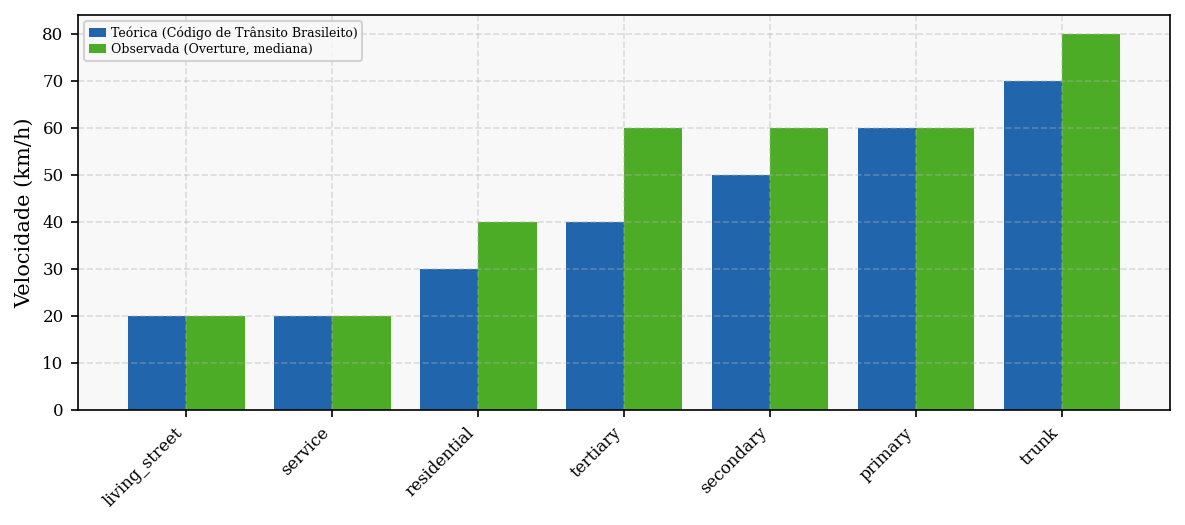

In [12]:
# ── Fig. 01 — Calibração: velocidade teórica vs. observada ──────────────────
d = calibracao.sort_values("teorica"); x = np.arange(len(d)); w = 0.4
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(x - w/2, d["teorica"], w, label="Teórica (Código de Trânsito Brasileito)", color="#2166AC")
ax.bar(x + w/2, d["observada_overture"], w, label="Observada (Overture, mediana)", color="#4DAC26")
ax.set_xticks(x); ax.set_xticklabels(d.index, rotation=45, ha="right")
ax.set_ylabel("Velocidade (km/h)"); ax.legend()
plt.tight_layout()
fig.savefig(FIGURAS_NB / "nb031_fig01_calibracao_velocidades.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Atrito urbano e impedância por modo

A velocidade de fluxo livre superestima o deslocamento real, que sofre com interseções,
semáforos e tráfego. Aplica-se, ao modo automóvel, um **fator de atrito de 0,70**
(redução de 30%), conforme a literatura de fricção urbana (Campanelli *et al.*, 2026).
O modo pedestre adota velocidade constante de 4,8 km/h, já representativa do caminhar
urbano (sem atrito adicional).

**Traversabilidade por modo:** em vez de remover arestas — o que romperia a topologia e
privaria o pedestre de calçadas —, atribui-se impedância **infinita** às arestas que cada
modo não pode percorrer: o automóvel não trafega em `footway/path/steps/pedestrian`; o
pedestre não percorre `motorway/trunk`. O NB 04 roteia cada modo descartando os custos
infinitos.

In [5]:
# ── 4. IMPEDÂNCIA POR MODO (minutos) ────────────────────────────────────────
FATOR_FRICCAO = 0.70          # atrito urbano (–30%) sobre a velocidade do automóvel
VELOCIDADE_PEDESTRE_KMH = 4.8 # caminhar urbano médio

CARRO_PROIBIDO = {"pedestrian", "footway", "path", "steps", "cycleway"}
PE_PROIBIDO    = {"motorway", "trunk"}

gdf["vel_carro"] = gdf["vel_teorica"] * FATOR_FRICCAO
dist_km = gdf["length_m"] / 1000.0

gdf["tempo_carro_min"] = np.where(classe.isin(CARRO_PROIBIDO), np.inf,
                                  dist_km / gdf["vel_carro"] * 60)
gdf["tempo_pe_min"] = np.where(classe.isin(PE_PROIBIDO), np.inf,
                               dist_km / VELOCIDADE_PEDESTRE_KMH * 60)

drivivel = ~classe.isin(CARRO_PROIBIDO)
andavel  = ~classe.isin(PE_PROIBIDO)
print(f"🚗 Dirigíveis: {drivivel.sum():,} | 🚶 Andáveis: {andavel.sum():,}")
print(f"   Tempo médio/aresta — carro: {gdf.loc[drivivel,'tempo_carro_min'].mean():.2f} min | "
      f"pé: {gdf.loc[andavel,'tempo_pe_min'].mean():.2f} min")

🚗 Dirigíveis: 51,181 | 🚶 Andáveis: 52,464
   Tempo médio/aresta — carro: 0.25 min | pé: 1.13 min


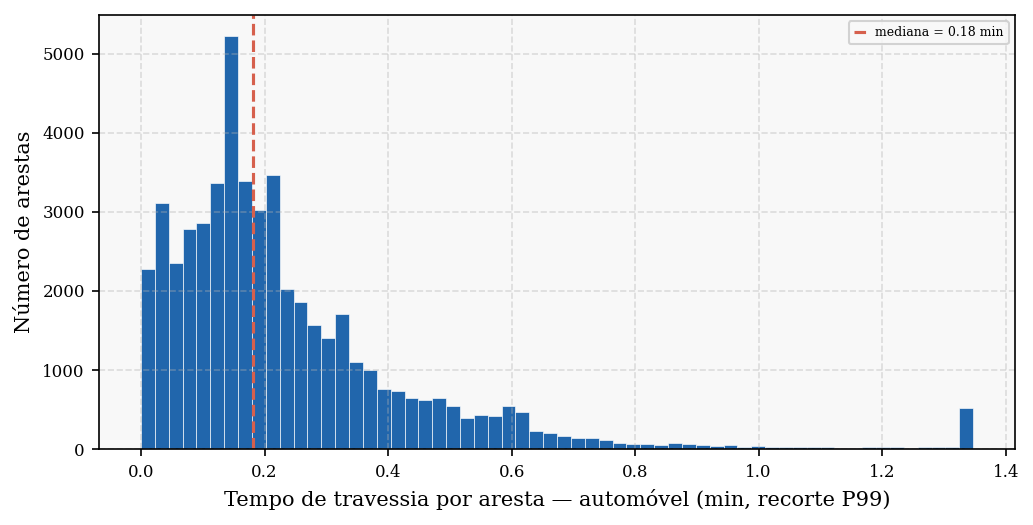

In [11]:
# ── Fig. 02 — Distribuição do tempo de travessia (carro) ────────────────────
tc = gdf.loc[drivivel, "tempo_carro_min"]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(tc.clip(upper=tc.quantile(0.99)), bins=60, color="#2166AC",
        edgecolor="white", linewidth=0.3)
ax.axvline(tc.median(), ls="--", color="#D6604D", label=f"mediana = {tc.median():.2f} min")
ax.set_xlabel("Tempo de travessia por aresta — automóvel (min, recorte P99)")
ax.set_ylabel("Número de arestas"); ax.legend()
plt.tight_layout()
fig.savefig(FIGURAS_NB / "nb031_fig02_hist_tempo_carro.png", dpi=300, bbox_inches="tight")
plt.show()

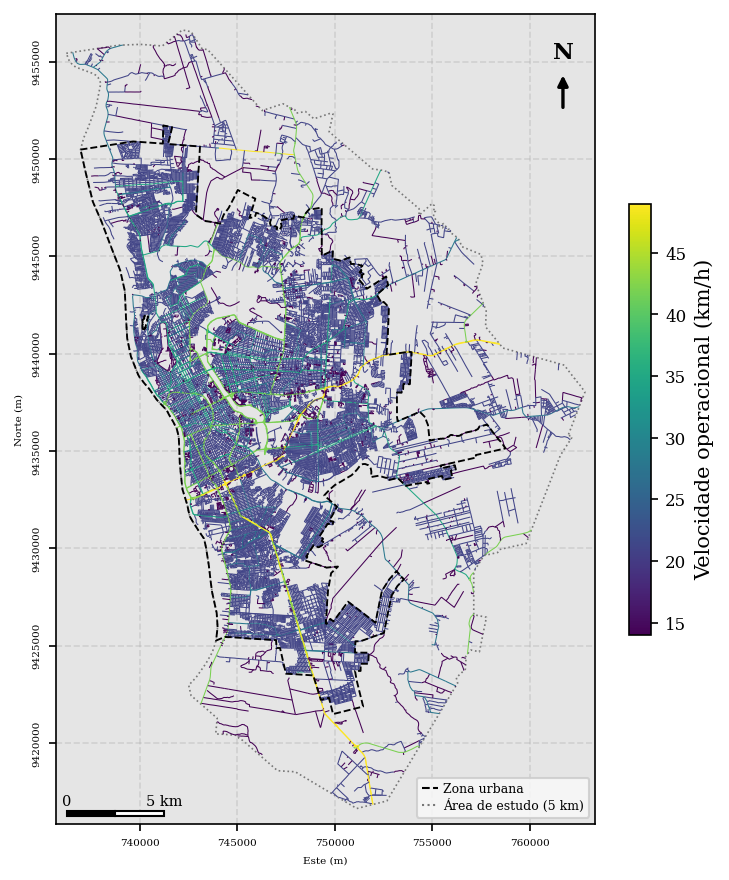

In [10]:
# ── Fig. 03 — Mapa da velocidade operacional (automóvel) ────────────────────
fig, ax = plt.subplots(figsize=(5.8, 8.3)); ax.set_facecolor("#E5E5E5")
area_estudo.boundary.plot(ax=ax, color="#777777", ls=":", lw=0.8, zorder=1)
gdf[drivivel].plot(ax=ax, column="vel_carro", cmap="viridis", linewidth=0.5, zorder=2,
                   legend=True, legend_kwds={"shrink": 0.45, "label": "Velocidade operacional (km/h)"})
zona_urbana.boundary.plot(ax=ax, color="black", ls="--", lw=0.9, zorder=3)
ax.legend(handles=[Line2D([], [], color="black", ls="--", lw=1, label="Zona urbana"),
                   Line2D([], [], color="#777777", ls=":", lw=1, label="Área de estudo (5 km)")],
          loc="lower right", fontsize=6, labelspacing=0.25, framealpha=0.85)
ajustar_zoom_camada(ax, area_estudo, margem=0.02)
formatar_eixos_mapa(ax, fontsize=5)
barra_escala(ax); seta_norte(ax)
fig.savefig(FIGURAS_NB / "nb031_fig03_mapa_velocidade.png", dpi=300, bbox_inches="tight")
plt.show()

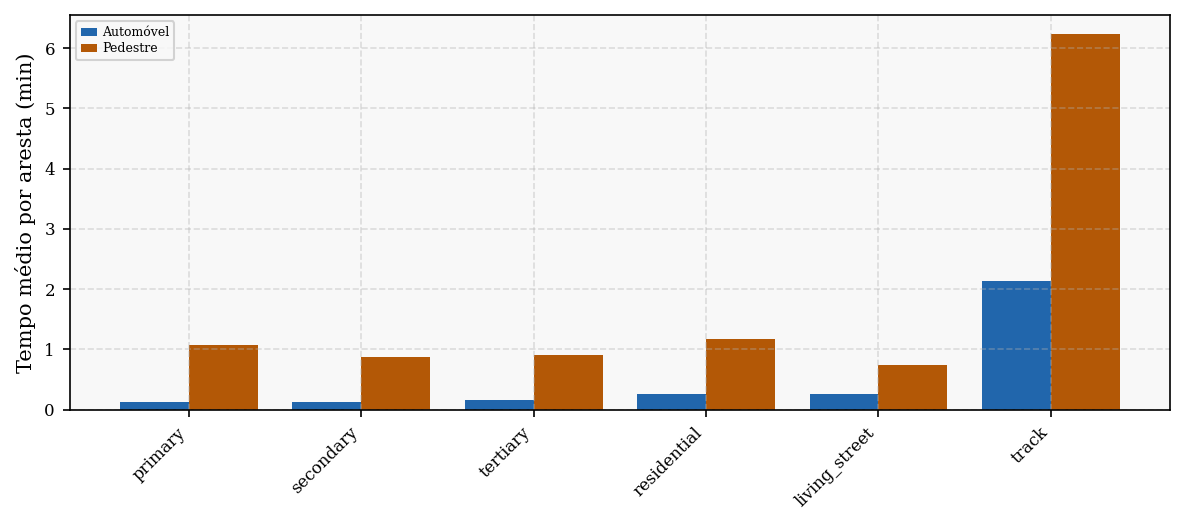

In [13]:
# ── Fig. 04 — Tempo médio por aresta: automóvel vs. pedestre ────────────────
classes_show = ["primary", "secondary", "tertiary", "residential", "living_street", "track"]
mc = [gdf.loc[classe == c, "tempo_carro_min"].replace(np.inf, np.nan).mean() for c in classes_show]
mp = [gdf.loc[classe == c, "tempo_pe_min"].replace(np.inf, np.nan).mean() for c in classes_show]
x = np.arange(len(classes_show)); w = 0.4
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(x - w/2, mc, w, label="Automóvel", color="#2166AC")
ax.bar(x + w/2, mp, w, label="Pedestre", color="#B35806")
ax.set_xticks(x); ax.set_xticklabels(classes_show, rotation=45, ha="right")
ax.set_ylabel("Tempo médio por aresta (min)"); ax.legend()
plt.tight_layout()
fig.savefig(FIGURAS_NB / "nb031_fig04_carro_vs_pedestre.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Validação e exportação

Verifica-se que os tempos do modo automóvel, nas vias dirigíveis, são finitos e não
negativos (pré-requisito do roteamento). O grafo enriquecido é salvo para o NB 04.

In [9]:
# ── 5. VALIDAÇÃO E EXPORTAÇÃO ───────────────────────────────────────────────
t = gdf.loc[drivivel, "tempo_carro_min"]
assert np.isfinite(t).all() and (t >= 0).all(), "Tempos inválidos no modo automóvel."
print(f"✅ Validação ok | arestas de comprimento zero: {(gdf['length_m'] == 0).sum()}")

caminho = INT_IMPEDANCIAS / "zonaUrbana_5km_road_routed.parquet"
gdf.to_parquet(caminho)
print(f"💾 Grafo com impedâncias salvo: {caminho}")

✅ Validação ok | arestas de comprimento zero: 36
💾 Grafo com impedâncias salvo: C:\Users\felipe\workspace_pcksa\ae2sfca_ubs\dados\intermediarios\04_impedancias\zonaUrbana_5km_road_routed.parquet


---
## Próximos passos
O **NB 04** usará as colunas `tempo_carro_min` e `tempo_pe_min` para gerar isócronas de
10, 20 e 30 minutos a partir de cada UBS, descartando, por modo, as arestas de custo
infinito.